In [90]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
#from matplotlib import colormaps
#import math

In [91]:
df = pd.read_excel("CuanticaP3.xlsx", sheet_name="Alex")

In [92]:
V = df["V"].to_numpy()*1000

#Error term
V = V + V*0.1

VErr = df["VErr"].to_numpy()*1000
D = df["d"].to_numpy()/100

#Error term
D = D + D*0.2

DErr = df["dErr"].to_numpy()/100

In [93]:
x = V
xerr = VErr
y = D
yerr = DErr

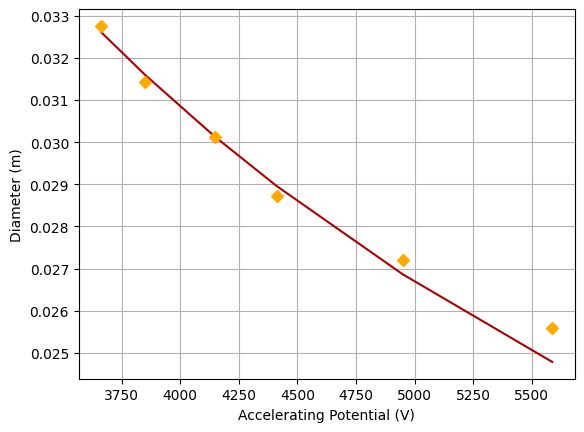

In [94]:
def funciondeajuste(t, a, intercept):
    return a * t**(-1/2) + intercept

popt, pcov = scipy.optimize.curve_fit(funciondeajuste, x, y, sigma = yerr)
a,b = popt
aerr, berr = np.sqrt(np.diag(pcov))

plt.plot(V, funciondeajuste(x, a, b), color = "#AA0000")
plt.errorbar(x, y, fmt='D', capsize=5, color = "#FFAA00")

plt.ylabel("Diameter (m)")
plt.xlabel("Accelerating Potential (V)")

plt.grid(True)

plt.savefig("CuanticaP3.png", dpi = 300)

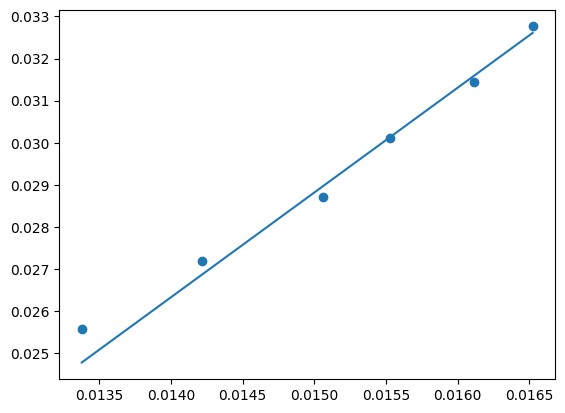

In [95]:
def lineal(x, slope, intercept):
    return slope * x + intercept

Vnegativesquare = V**(-1/2)


popt2, pcov2 = scipy.optimize.curve_fit(lineal, Vnegativesquare, D, sigma = DErr)
aLin, bLin = popt2

plt.plot(Vnegativesquare, lineal(Vnegativesquare, *popt2))
plt.scatter(Vnegativesquare, D)



In [96]:
#Calculate chicuadradoreducido
residuals = y - funciondeajuste(x, *popt)
chi2 = np.sum((residuals/yerr)**2)
chi2_red = chi2/(len(x)-len(popt))

#Calculate errecuadrado
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print("Chi^2 reducido = " + str(chi2_red))
print("R^2 = " + str(r_squared**2))

Chi^2 reducido = 87.49256481830469
R^2 = 0.9531118413998654


In [97]:
R = 0.065
h = 6.626E-34
m = 9.11E-31
e = 1.60E-19

d2 = 4*R*h/(a*np.sqrt(2*m*e))
d2err = 4*R*h/((a**2)*np.sqrt(2*m*e))*aerr
#d2lineal = 4*R*h/(aLin*np.sqrt(2*m*e))

d2Theo = 123e-12
d2RelativeError = abs(d2Theo - d2) / d2Theo


print("a = " + str(a) + " pm " + str(aerr))
print("b = " + str(b) + " pm " + str(berr))

print("Distancia interplanar d2 = " + str(d2*1e12) + " +- " + str(d2err*1e12) + " pm, abs.err = " + str(d2RelativeError*100) + "%")
#print(d2lineal)

a = 2.4868536543041526 pm 0.15167874541051626
b = -0.008481613047399958 pm 0.002429966154731919
Distancia interplanar d2 = 128.30405227984198 +- 7.825550026721259 pm, abs.err = 4.312237625887792%
